# Speckle-Noise Removal for Breast Ultrasound Images

A CNN denoiser trained with **knowledge distillation**. A 16-block student
network learns to remove synthetic speckle noise; a U-Net teacher adds an
extra distillation term to the loss.

The notebook is split into 11 sections. Run them in order, top to bottom.
Section 4 only needs to run once, as long as the generated PNG folders exist.

## 1. Imports

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from scipy.ndimage import convolve
from skimage import color
from skimage.metrics import structural_similarity as compare_ssim
from skimage.metrics import mean_squared_error
from skimage.util import img_as_float, random_noise

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import (Input, Conv2D, Conv2DTranspose, MaxPooling2D,
                                     BatchNormalization, LeakyReLU, Dropout,
                                     concatenate)
from tensorflow.keras.losses import MeanSquaredError, KLDivergence
from tensorflow.keras.models import Model

# Let the GPU grow its allocation on demand instead of grabbing everything
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

## 2. Configuration

Every tunable value and every path lives in this cell. Change them here only.

In [ ]:
# ----- Image / patch geometry -----
IMAGE_SIZE = (256, 256)     # every image is resized to this
PATCH_SIZE = 64             # side length of the square patches fed to the network
CHANNELS = 3                # images are read as BGR by OpenCV

# ----- Speckle noise -----
NOISE_STDDEV = 0.01         # std-dev of the multiplicative noise

# ----- Dataset preparation -----
VAL_SPLIT = 0.3             # fraction of the train folder used for validation
AUG_BATCH_SIZE = 64         # batch size of the augmentation generators
MAX_TRAIN_BATCHES = 40      # batches pulled from the train generator
MAX_VAL_BATCHES = 10        # batches pulled from the validation generator
MAX_TEST_BATCHES = 2        # batches pulled from the test generator

# ----- Training / evaluation -----
TRAIN_BATCH_SIZE = 32       # batch size of model.fit and of the evaluation loop
EPOCHS = 100
LEARNING_RATE = 5e-4
ADAM_BETA_1 = 0.7
ADAM_BETA_2 = 0.999

# ----- Knowledge distillation -----
DISTILLATION_WEIGHT = 0.4
DISTILLATION_TEMPERATURE = 0.8

# ----- Teacher / learning-rate schedule -----
TEACHER_LEARNING_RATE = 1e-3
LR_REDUCE_FACTOR = 0.8
LR_REDUCE_PATIENCE = 3
LR_MIN = 1e-10

# ----- Student architecture -----
N_CONV_BLOCKS = 16          # 16 x [Conv 3x3 (64) -> BatchNorm -> LeakyReLU]
STUDENT_FILTERS = 64
STUDENT_DENSE_UNITS = 512

# ----- Input datasets (Kaggle paths) -----
DATA_TRAIN_DIR = "../input/breast-dataset/Breast_Dataset/train"
DATA_TEST_DIR = "../input/breast-dataset/Breast_Dataset/test"
SAMPLE_IMAGE_PATH = "../input/breast-dataset/Breast_Dataset/test/normal/normal (1).png"

# ----- Generated clean / noisy pairs -----
WORK_DIR = "/kaggle/working"
TRAIN_CLEAN_DIR = f"{WORK_DIR}/train_data_clean"
TRAIN_NOISY_DIR = f"{WORK_DIR}/train_data_noisy"
VAL_CLEAN_DIR = f"{WORK_DIR}/val_data_clean"
VAL_NOISY_DIR = f"{WORK_DIR}/val_data_noisy"
TEST_CLEAN_DIR = f"{WORK_DIR}/test_data_clean"
TEST_NOISY_DIR = f"{WORK_DIR}/test_data_noisy"

# ----- Files written by the visual check -----
NOISY_SAMPLE_OUT = "noisy_image.png"
DENOISED_SAMPLE_OUT = "denoised_image.png"

## 3. Function declarations

Everything the later sections call is defined here, so the notebook can be read
top to bottom without jumping around.

### 3.1 Speckle noise

In [ ]:
def add_speckle_noise_pil(clean_image, noise_stddev):
    '''Add multiplicative speckle noise to a PIL image. Returns float array in [0, 1].'''
    width, height = clean_image.size
    shape = (height, width, len(clean_image.getbands()))
    clean = img_as_float(clean_image)
    noisy = clean + clean * np.random.normal(loc=0, scale=noise_stddev, size=shape)
    return np.clip(noisy, 0.0, 1.0)


def add_speckle_noise_array(image, noise_stddev):
    '''Same noise model, but for an ndarray that is already in [0, 1].'''
    noisy = image + image * np.random.normal(loc=0, scale=noise_stddev, size=image.shape)
    return np.clip(noisy, 0.0, 1.0)

### 3.2 Dataset preparation helpers

In [ ]:
def to_uint8_image(array_01):
    '''Float array in [0, 1] -> PIL image (uint8).'''
    return Image.fromarray((array_01 * 255).astype(np.uint8))


def save_clean_noisy_pairs(generator, max_batches, batch_size, clean_dir, noisy_dir, noise_stddev):
    '''
    Pull at most `max_batches` batches from a Keras image generator and write each
    image to `clean_dir` plus a speckle-noised copy (same file name) to `noisy_dir`.
    Returns the number of pairs written.
    '''
    count = 0
    for i in range(min(generator.n, max_batches)):
        images = next(generator)[0]
        for j in range(len(images)):
            clean = to_uint8_image(images[j])
            name = f"{i * batch_size + j}.png"
            clean.save(os.path.join(clean_dir, name))

            noisy = to_uint8_image(add_speckle_noise_pil(clean, noise_stddev))
            noisy.save(os.path.join(noisy_dir, name))
            count += 1
    return count


def read_images(path):
    '''Read every image in a folder (BGR via OpenCV), scaled to [0, 1].'''
    data = []
    for fname in os.listdir(path):
        if fname != ".DS_Store":
            im = cv2.imread(os.path.join(path, fname))
            data.append(im / 255.0)
    return np.array(data)

### 3.3 Patch extraction and reconstruction

In [ ]:
def extract_patches(images, patch_size):
    '''Cut each image into non-overlapping patches. Returns (N_total, p, p, 3).'''
    all_patches = []
    for image in images:
        patches = []
        for i in range(0, image.shape[0] - patch_size + 1, patch_size):
            for j in range(0, image.shape[1] - patch_size + 1, patch_size):
                patches.append(image[i:i + patch_size, j:j + patch_size, :])
        all_patches.append(np.array(patches))
    all_patches = np.stack(all_patches, axis=0)
    return all_patches.reshape(-1, patch_size, patch_size, 3)


def reconstruct_image(patches, original_shape):
    '''Inverse of extract_patches for a single image (row-major patch order).'''
    patch_size = patches.shape[1]
    full_image = np.zeros(original_shape)
    index = 0
    for i in range(0, original_shape[0] - patch_size + 1, patch_size):
        for j in range(0, original_shape[1] - patch_size + 1, patch_size):
            full_image[i:i + patch_size, j:j + patch_size, :] = patches[index]
            index += 1
    return full_image

### 3.4 Metrics

In [ ]:
def peak_signal_noise_ratio(y_true, y_pred):
    '''Keras metric: PSNR for images in [0, 1].'''
    return tf.image.psnr(y_pred, y_true, max_val=1.0)


def compute_niqe(image):
    '''Simplified NIQE-style score: mean of |mu| and |sigma| of a Gaussian-filtered image.'''
    kernel = np.array([[1, 4, 6, 4, 1],
                       [4, 16, 24, 16, 4],
                       [6, 24, 36, 24, 6],
                       [4, 16, 24, 16, 4],
                       [1, 4, 6, 4, 1]]) / 256.0
    gray = color.rgb2gray(image)
    filtered = convolve(gray, kernel, mode='nearest')
    features = np.array([filtered.mean(), filtered.std()])
    return np.mean(np.abs(features))


def calculate_metrics(enhanced_images, ground_truth_images):
    '''
    Average PSNR, SSIM, CNR, ENL, EPI, MSE, RMSE, FOM and NIQE over a batch.
    Returns them in exactly that order.
    '''
    psnr_v, ssim_v, cnr_v, enl_v, epi_v = [], [], [], [], []
    mse_v, rmse_v, fom_v, niqe_v = [], [], [], []

    for i in range(len(enhanced_images)):
        enhanced = enhanced_images[i]
        truth = ground_truth_images[i]
        enhanced = np.expand_dims(enhanced, axis=0)

        if not isinstance(enhanced, np.ndarray) or not isinstance(truth, np.ndarray):
            print(f"Skipping image {i + 1} due to an invalid format.")
            continue

        # MSE, then PSNR derived from it
        mse = np.mean((enhanced - truth) ** 2)
        mse_v.append(mse)
        psnr_v.append(100 if mse == 0 else 10 * np.log10(1.0 / mse))

        # SSIM
        ssim_v.append(compare_ssim(enhanced[0], truth, win_size=3, data_range=1.0))

        # CNR: signal mean over the std of the residual
        mean_signal = np.mean(truth)
        mean_noise = np.mean(enhanced - truth)
        std_noise = np.std(enhanced - truth)
        cnr_v.append(0 if std_noise < 1e-6 else np.abs(mean_signal - mean_noise) / std_noise)

        # ENL: mean / std squared
        mean_val, std_val = np.mean(enhanced), np.std(enhanced)
        enl_v.append((mean_val / std_val) ** 2)

        # EPI and FOM, both from the gradient difference
        g_truth = np.gradient(truth)
        g_enh = np.gradient(enhanced[0])
        diff = np.abs(g_truth[0] - g_enh[0]) + np.abs(g_truth[1] - g_enh[1])
        epi_v.append(np.mean(diff))
        fom_v.append(np.exp(-1 * np.mean(diff)))

        # RMSE
        rmse_v.append(np.sqrt(mean_squared_error(truth, enhanced[0])))

        # NIQE
        niqe_v.append(compute_niqe(enhanced[0]))

    return (np.mean(psnr_v), np.mean(ssim_v), np.mean(cnr_v), np.mean(enl_v), np.mean(epi_v),
            np.mean(mse_v), np.mean(rmse_v), np.mean(fom_v), np.mean(niqe_v))

### 3.5 Visualisation helpers

In [ ]:
def denoise_image_by_patches(model, noisy_patches, image_shape, patch_size):
    '''Denoise every patch on its own and stitch the results back together.'''
    denoised = [model.predict(np.expand_dims(p, axis=0), verbose=0)[0] for p in noisy_patches]
    return reconstruct_image(np.array(denoised), image_shape)


def visualize_sample_image(clean_image, noisy_image, denoised_image):
    '''Show clean / noisy / denoised side by side and save the noisy and denoised PNGs.'''
    cv2.imwrite(NOISY_SAMPLE_OUT, noisy_image * 255)
    cv2.imwrite(DENOISED_SAMPLE_OUT, denoised_image * 255)

    plt.figure(figsize=(12, 4))
    for idx, (title, img) in enumerate([("Original Sample Image", clean_image),
                                        ("Noisy Sample Image", noisy_image),
                                        ("Denoised Sample Image", denoised_image)], start=1):
        plt.subplot(1, 3, idx)
        plt.title(title)
        plt.imshow(img, cmap=plt.cm.gray)
        plt.axis('off')
    plt.show()


def plot_training_history(history):
    '''Plot the loss and accuracy curves, train against validation.'''
    plt.figure(figsize=(12, 4))
    for idx, (key, title) in enumerate([('loss', 'Model Loss'),
                                        ('accuracy', 'Model Accuracy')], start=1):
        plt.subplot(1, 2, idx)
        plt.plot(history.history[key], label='Train')
        plt.plot(history.history[f'val_{key}'], label='Validation')
        plt.title(title)
        plt.xlabel('Epoch')
        plt.ylabel(key.capitalize())
        plt.legend()
    plt.show()

## 4. Dataset preparation

1. Create the six output folders.
2. Build the generators. Train and validation come from the same train folder,
   split by `VAL_SPLIT`, and both are augmented (rotation up to 20 degrees,
   horizontal and vertical flips). The test generator is not augmented.
3. Write every image twice: the clean one and a speckle-noised copy under the
   same file name.

`class_mode='input'` makes each generator return the image as its own target,
which is what unsupervised despeckling needs. A Keras generator loops forever,
so asking for `MAX_TRAIN_BATCHES` batches returns more images than the folder
contains; the extras are fresh random augmentations.

**This section only has to run once.** Later runs can skip it as long as the
generated folders still exist.

In [ ]:
for directory in (TRAIN_CLEAN_DIR, TRAIN_NOISY_DIR, VAL_CLEAN_DIR,
                  VAL_NOISY_DIR, TEST_CLEAN_DIR, TEST_NOISY_DIR):
    os.makedirs(directory, exist_ok=True)

In [ ]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=VAL_SPLIT,
)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
)

train_data = train_datagen.flow_from_directory(
    DATA_TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=AUG_BATCH_SIZE,
    class_mode='input', shuffle=True, subset='training')

val_data = train_datagen.flow_from_directory(
    DATA_TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=AUG_BATCH_SIZE,
    class_mode='input', shuffle=True, subset='validation')

test_data = test_datagen.flow_from_directory(
    DATA_TEST_DIR, target_size=IMAGE_SIZE, batch_size=AUG_BATCH_SIZE,
    class_mode='input', shuffle=False)

print(f"train batches : {train_data.n // AUG_BATCH_SIZE}")
print(f"valid batches : {val_data.n // AUG_BATCH_SIZE}")
print(f"test batches  : {test_data.n // AUG_BATCH_SIZE}")
print(f"train_data.n  : {train_data.n}")

Found 453 images belonging to 2 classes.
Found 194 images belonging to 2 classes.
Found 133 images belonging to 1 classes.
train_batches : 7 patch
valid_batches : 3 patch
test_clean_batches : 2 patch
train_data.n : 453 patch
2265
2265
516
516
128
128


In [ ]:
n_train = save_clean_noisy_pairs(train_data, MAX_TRAIN_BATCHES, AUG_BATCH_SIZE,
                                 TRAIN_CLEAN_DIR, TRAIN_NOISY_DIR, NOISE_STDDEV)
n_val = save_clean_noisy_pairs(val_data, MAX_VAL_BATCHES, AUG_BATCH_SIZE,
                               VAL_CLEAN_DIR, VAL_NOISY_DIR, NOISE_STDDEV)
n_test = save_clean_noisy_pairs(test_data, MAX_TEST_BATCHES, AUG_BATCH_SIZE,
                                TEST_CLEAN_DIR, TEST_NOISY_DIR, NOISE_STDDEV)

print(f"train pairs: {n_train}, validation pairs: {n_val}, test pairs: {n_test}")

# The generators are no longer needed
del train_datagen, test_datagen, train_data, val_data, test_data

## 5. Load the PNG pairs and cut them into patches

Every 256x256 image becomes 16 non-overlapping 64x64 patches, and both models
work on patches only.

In [ ]:
train_d_clean = read_images(TRAIN_CLEAN_DIR)
train_d_noisy = read_images(TRAIN_NOISY_DIR)
val_d_clean = read_images(VAL_CLEAN_DIR)
val_d_noisy = read_images(VAL_NOISY_DIR)
test_d_clean = read_images(TEST_CLEAN_DIR)
test_d_noisy = read_images(TEST_NOISY_DIR)

print("train images:", train_d_clean.shape)

(2265, 256, 256, 3)
train_data_clean : 36240 images
train_data_noisy : 36240 images
valid_data_clean : 8256 images
valid_data_noisy : 8256 images
test_data_clean : 2048 images
test_data_noisy : 2048 images


In [ ]:
train_data_clean = extract_patches(train_d_clean, PATCH_SIZE)
train_data_noisy = extract_patches(train_d_noisy, PATCH_SIZE)
val_data_clean = extract_patches(val_d_clean, PATCH_SIZE)
val_data_noisy = extract_patches(val_d_noisy, PATCH_SIZE)
test_data_clean = extract_patches(test_d_clean, PATCH_SIZE)
test_data_noisy = extract_patches(test_d_noisy, PATCH_SIZE)

for name, arr in [("train_data_clean", train_data_clean),
                  ("train_data_noisy", train_data_noisy),
                  ("val_data_clean", val_data_clean),
                  ("val_data_noisy", val_data_noisy),
                  ("test_data_clean", test_data_clean),
                  ("test_data_noisy", test_data_noisy)]:
    print(f"{name} : {len(arr)} patches")

## 6. Model declarations

### 6.1 Student: the denoising CNN

`N_CONV_BLOCKS` (= 16) repetitions of Conv 3x3 with 64 filters, BatchNorm and
LeakyReLU(0.2), then a Dense layer and a final 3-channel Conv with a linear
activation, so the network can output values outside [0, 1].

That is 16 x 3 = 48 weight layers, plus the Dense layer and the output Conv.

In [ ]:
def build_student(n_blocks=N_CONV_BLOCKS, filters=STUDENT_FILTERS,
                  dense_units=STUDENT_DENSE_UNITS):
    '''Returns (student, mse_loss, kl_loss, optimizer).'''
    blocks = [layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, CHANNELS))]
    for _ in range(n_blocks):
        blocks += [layers.Conv2D(filters, (3, 3), padding='same'),
                   layers.BatchNormalization(),
                   layers.LeakyReLU(negative_slope=0.2)]
    blocks += [layers.Dense(dense_units),
               layers.Conv2D(CHANNELS, (3, 3), activation='linear', padding='same')]

    student = tf.keras.Sequential(blocks)
    return student, MeanSquaredError(), KLDivergence(), tf.keras.optimizers.Adam()

### 6.2 Teacher: U-Net

Four down-sampling stages (64 -> 128 -> 256 -> 512 filters) and a 1024-filter
bottleneck. Every stage is three Conv-BatchNorm-LeakyReLU layers. Dropout of
0.5 sits at the two deepest levels, skip connections join the way up, and the
output is a sigmoid convolution.

The last convolution keeps the default `padding='valid'`, so the teacher output
is 62x62. `custom_loss` resizes it back to 64x64.

In [ ]:
def conv_block(x, filters, n_convs=3):
    '''n_convs x (Conv 3x3 -> BatchNorm -> LeakyReLU).'''
    for _ in range(n_convs):
        x = Conv2D(filters, (3, 3), padding='same')(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(negative_slope=0.2)(x)
    return x


def build_teacher_model(input_shape=(PATCH_SIZE, PATCH_SIZE, CHANNELS)):
    '''Builds the U-Net teacher that supplies the distillation term.'''
    inputs = Input(shape=input_shape)

    # Contraction path
    conv1 = conv_block(inputs, 64);    pool1 = MaxPooling2D((2, 2))(conv1)
    conv2 = conv_block(pool1, 128);    pool2 = MaxPooling2D((2, 2))(conv2)
    conv3 = conv_block(pool2, 256);    pool3 = MaxPooling2D((2, 2))(conv3)
    conv4 = conv_block(pool3, 512);    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D((2, 2))(drop4)

    # Bottleneck
    conv5 = conv_block(pool4, 1024);   drop5 = Dropout(0.5)(conv5)

    # Expansion path with skip connections
    up6 = Conv2DTranspose(512, (3, 3), strides=(2, 2), padding='same')(drop5)
    conv6 = conv_block(concatenate([up6, drop4]), 512)

    up7 = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(conv6)
    conv7 = conv_block(concatenate([up7, conv3]), 256)

    up8 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(conv7)
    conv8 = conv_block(concatenate([up8, conv2]), 128)

    up9 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(conv8)
    conv9 = conv_block(concatenate([up9, conv1]), 64)

    # 'valid' padding, so this map is 62x62; the loss resizes it
    outputs = Conv2D(CHANNELS, (3, 3), activation='sigmoid')(conv9)
    return Model(inputs=[inputs], outputs=[outputs])

### 6.3 Custom loss

```
total = ( MSE + (1 - SSIM) + L1 + w * KL(teacher || student) ) / PSNR
```

with `w = DISTILLATION_WEIGHT` and temperature `T = DISTILLATION_TEMPERATURE`.
The teacher is fed `y_true` (the clean patch), and both outputs go through a
temperature-scaled softmax over the channel axis before the KL term.

The loss reads the module-level names `teacher_model` and `gen_loss_function`,
so section 7 has to build both before the student is compiled.

In [ ]:
def custom_loss(distillation_weight=DISTILLATION_WEIGHT,
                temperature=DISTILLATION_TEMPERATURE, epsilon=1e-10):
    '''
    Build the distillation + reconstruction loss.
    Relies on the globals `teacher_model` and `gen_loss_function`
    (both created in section 7, before compiling).
    '''
    def loss(y_true, y_pred):
        gen_loss = gen_loss_function(y_true, y_pred)
        ssim = 1.0 - tf.image.ssim(y_true, y_pred, max_val=1.0)
        l1 = tf.reduce_mean(tf.abs(y_true - y_pred))

        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        psnr = tf.cond(tf.equal(mse, 0),
                       lambda: tf.constant(0, dtype=tf.float32),
                       lambda: 10.0 * tf.math.log(1.0 / mse) / tf.math.log(10.0))

        if teacher_model is not None:
            teacher_predictions = teacher_model(y_true, training=False)

            scaled_teacher = tf.nn.softmax(teacher_predictions / temperature, axis=-1)
            scaled_student = tf.nn.softmax(y_pred / temperature, axis=-1)

            # The teacher output is 62x62, so resize it to the student's 64x64
            scaled_teacher = tf.image.resize(scaled_teacher, tf.shape(y_pred)[1:3])

            distillation = tf.reduce_sum(
                scaled_teacher * (temperature ** 2)
                * tf.math.log((scaled_teacher + epsilon) / (scaled_student + epsilon)),
                axis=-1)
            distillation = tf.reduce_mean(distillation)

            total_loss = (gen_loss + distillation_weight * distillation + ssim + l1) / psnr
        else:
            total_loss = (gen_loss + ssim + l1) / psnr

        return total_loss
    return loss

## 7. Build and compile

The teacher is built first because `custom_loss` closes over the global name
`teacher_model`. Note that the teacher is **compiled but never trained** here,
so the distillation term is measured against a randomly initialised U-Net.

In [ ]:
# Teacher
teacher_model = build_teacher_model()
teacher_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TEACHER_LEARNING_RATE,
                                       beta_1=0.9, beta_2=0.999),
    loss='mean_squared_error',
    metrics=['accuracy'],
)

# Student
generator, gen_loss_function, distillation_loss_function, generator_optimizer = build_student()

generator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE,
                                       beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2),
    loss=custom_loss(),
    metrics=['mse', 'accuracy', peak_signal_noise_ratio],
)

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_peak_signal_noise_ratio',
    patience=LR_REDUCE_PATIENCE, verbose=1,
    factor=LR_REDUCE_FACTOR, min_lr=LR_MIN,
)

## 8. Training

`model.fit` pairs every noisy patch with its clean counterpart. The learning
rate is cut by 20 % whenever `val_peak_signal_noise_ratio` stops improving for
3 epochs.

In [ ]:
print("fit start")
history = generator.fit(
    x=train_data_noisy,
    y=train_data_clean,
    batch_size=TRAIN_BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(val_data_noisy, val_data_clean),
    verbose=1,
    callbacks=[learning_rate_reduction],
)
print("fit end")

# The training arrays are no longer needed and are large
del train_data_clean, train_data_noisy, val_data_clean, val_data_noisy

fit start
Epoch 1/100
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 175s 132ms/step - accuracy: 0.3367 - loss: 0.0128 - mse: 0.0094 - peak_signal_noise_ratio: 25.4884 - val_accuracy: 0.5968 - val_loss: 0.0036 - val_mse: 0.0038 - val_peak_signal_noise_ratio: 27.8348 - learning_rate: 5.0000e-04
Epoch 2/100
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 134s 119ms/step - accuracy: 0.3263 - loss: 0.0022 - mse: 0.0018 - peak_signal_noise_ratio: 30.5721 - val_accuracy: 0.0662 - val_loss: 0.0021 - val_mse: 0.0015 - val_peak_signal_noise_ratio: 30.1258 - learning_rate: 5.0000e-04
Epoch 3/100
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 134s 119ms/step - accuracy: 0.3225 - loss: 0.0016 - mse: 0.0014 - peak_signal_noise_ratio: 31.9693 - val_accuracy: 0.1691 - val_loss: 0.0027 - val_mse: 0.0032 - val_peak_signal_noise_ratio: 28.7034 - learning_rate: 5.0000e-04
Epoch 4/100
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3291 - loss: 0.0014 - mse: 0.0012 - peak_signal_noise_ratio: 32.4548
Epoch 4: ReduceLROnPlateau reducing learnin

## 9. Evaluation on the test patches

The test patches are denoised batch by batch and each metric is averaged twice:
once inside `calculate_metrics` over a batch, then once more over the batches.
Integer division drops the last partial batch.

In [ ]:
METRIC_ORDER = ["PSNR", "SSIM", "MSE", "CNR", "ENL", "EPI", "RMSE", "FOM", "NIQE"]

per_batch = {name: [] for name in METRIC_ORDER}

num_batches = len(test_data_noisy) // TRAIN_BATCH_SIZE
for b in range(num_batches):
    start = b * TRAIN_BATCH_SIZE
    end = (b + 1) * TRAIN_BATCH_SIZE

    enhanced = generator.predict(test_data_noisy[start:end], verbose=0)
    values = calculate_metrics(enhanced, test_data_clean[start:end])
    for name, value in zip(METRIC_ORDER, values):
        per_batch[name].append(value)

avg = {name: float(np.mean(values)) for name, values in per_batch.items()}
for name in METRIC_ORDER:
    print(f"Average {name}: {avg[name]:.5f}")

In [ ]:
metric = pd.DataFrame(avg, index=['DNCNN'])[METRIC_ORDER]
metric

,PSNR,SSIM,MSE,CNR,ENL,EPI,RMSE,FOM,NIQE
DNCNN,47.768324,0.995471,0.000027,80.294019,9.111076,0.003567,0.004514,0.99644,0.206399


In [ ]:
evaluation_result = generator.evaluate(test_data_noisy, test_data_clean)

print("Test Loss:", evaluation_result[0])
print("Test Mean Squared Error:", evaluation_result[1])
# 'accuracy' is not a meaningful metric for image regression; use PSNR and SSIM
print("Test Accuracy:", evaluation_result[2] * 100)

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.2339 - loss: 1.3034e-04 - mse: 2.9510e-05 - peak_signal_noise_ratio: 47.5467
Test Loss: 0.00013264712470117956
Test Mean Squared Error: 2.6940910174744204e-05
Test Accuracy: 23.234760761260986


## 10. Visual check on one sample image

A test image is noised with `skimage`'s speckle mode, cut into 16 patches,
denoised one by one, and stitched back together. The noisy and denoised images
are also written to disk.

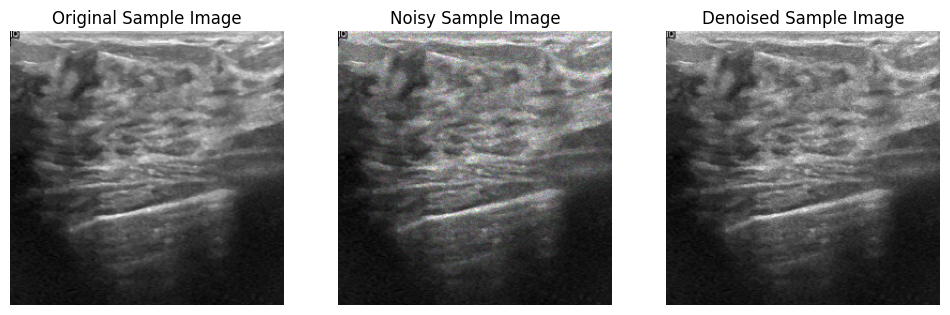

In [ ]:
sample_image = cv2.resize(cv2.imread(SAMPLE_IMAGE_PATH), IMAGE_SIZE) / 255.0
noisy_image = random_noise(sample_image, mode='speckle', var=NOISE_STDDEV, clip=True)

noisy_patches = extract_patches(np.array([noisy_image]), PATCH_SIZE)
denoised_image = denoise_image_by_patches(
    generator, noisy_patches, (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS), PATCH_SIZE)

visualize_sample_image(sample_image, noisy_image, denoised_image)

## 11. Training curves and model summaries

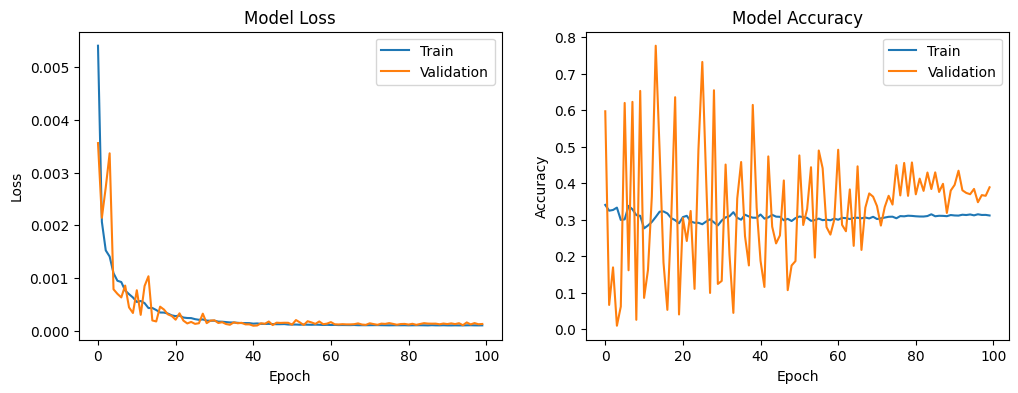

In [ ]:
plot_training_history(history)

In [ ]:
generator.summary()
teacher_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)                   │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_27 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_28 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_29 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_30 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_31               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_31 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_32               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_32 (LeakyReLU)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,816,651 (6.93 MB)

 Trainable params: 604,867 (2.31 MB)

 Non-trainable params: 2,048 (8.00 KB)

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 64)     │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 64, 64, 64)     │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 64, 64, 64)     │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ leaky_re_lu[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 64, 64, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 64, 64, 64)     │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ leaky_re_lu_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 64)     │            256 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 32, 32, 64)     │              0 │ leaky_re_lu_2[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 32, 32, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU) │ (None, 32, 32, 128)    │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ leaky_re_lu_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 32, 32, 128)    │            512 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_4 (LeakyR

 Total params: 50,257,347 (191.72 MB)

 Trainable params: 50,239,683 (191.65 MB)

 Non-trainable params: 17,664 (69.00 KB)